In [25]:
# Cell 1: Visualization Function
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams

def plot_ieee_confusion_matrix(conf_matrix, class_names, report_text=None, figsize=(12,10), dpi=300):
    """Create publication-quality confusion matrix visualization."""
    rcParams.update({'font.size': 12, 'font.family': 'serif'})
    
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    plt.grid(False)
    
    # Normalize matrix
    norm_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
    
    # Create heatmap
    sns.heatmap(norm_matrix, annot=True, fmt='.2f', cmap='Blues',
                cbar=True, ax=ax, annot_kws={'size':14},
                linewidths=0.5, linecolor='black')
    
    # Axis formatting
    # ax.set_xticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=0)
    ax.set_yticklabels(class_names, rotation=0)
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    
    # Add classification report
    # if report_text:
    #     plt.text(0.5, -0.35, report_text, 
    #              ha='center', va='center', 
    #              transform=ax.transAxes,
    #              bbox=dict(facecolor='white', alpha=0.8))
    
    # Add colorbar label
    cbar = ax.collections[0].colorbar
    cbar.set_label('Normalized Accuracy', rotation=270, labelpad=20)
    
    plt.tight_layout()
    # plt.savefig('confusion_matrix_ieee.png', bbox_inches='tight', dpi=dpi)
    plt.show()

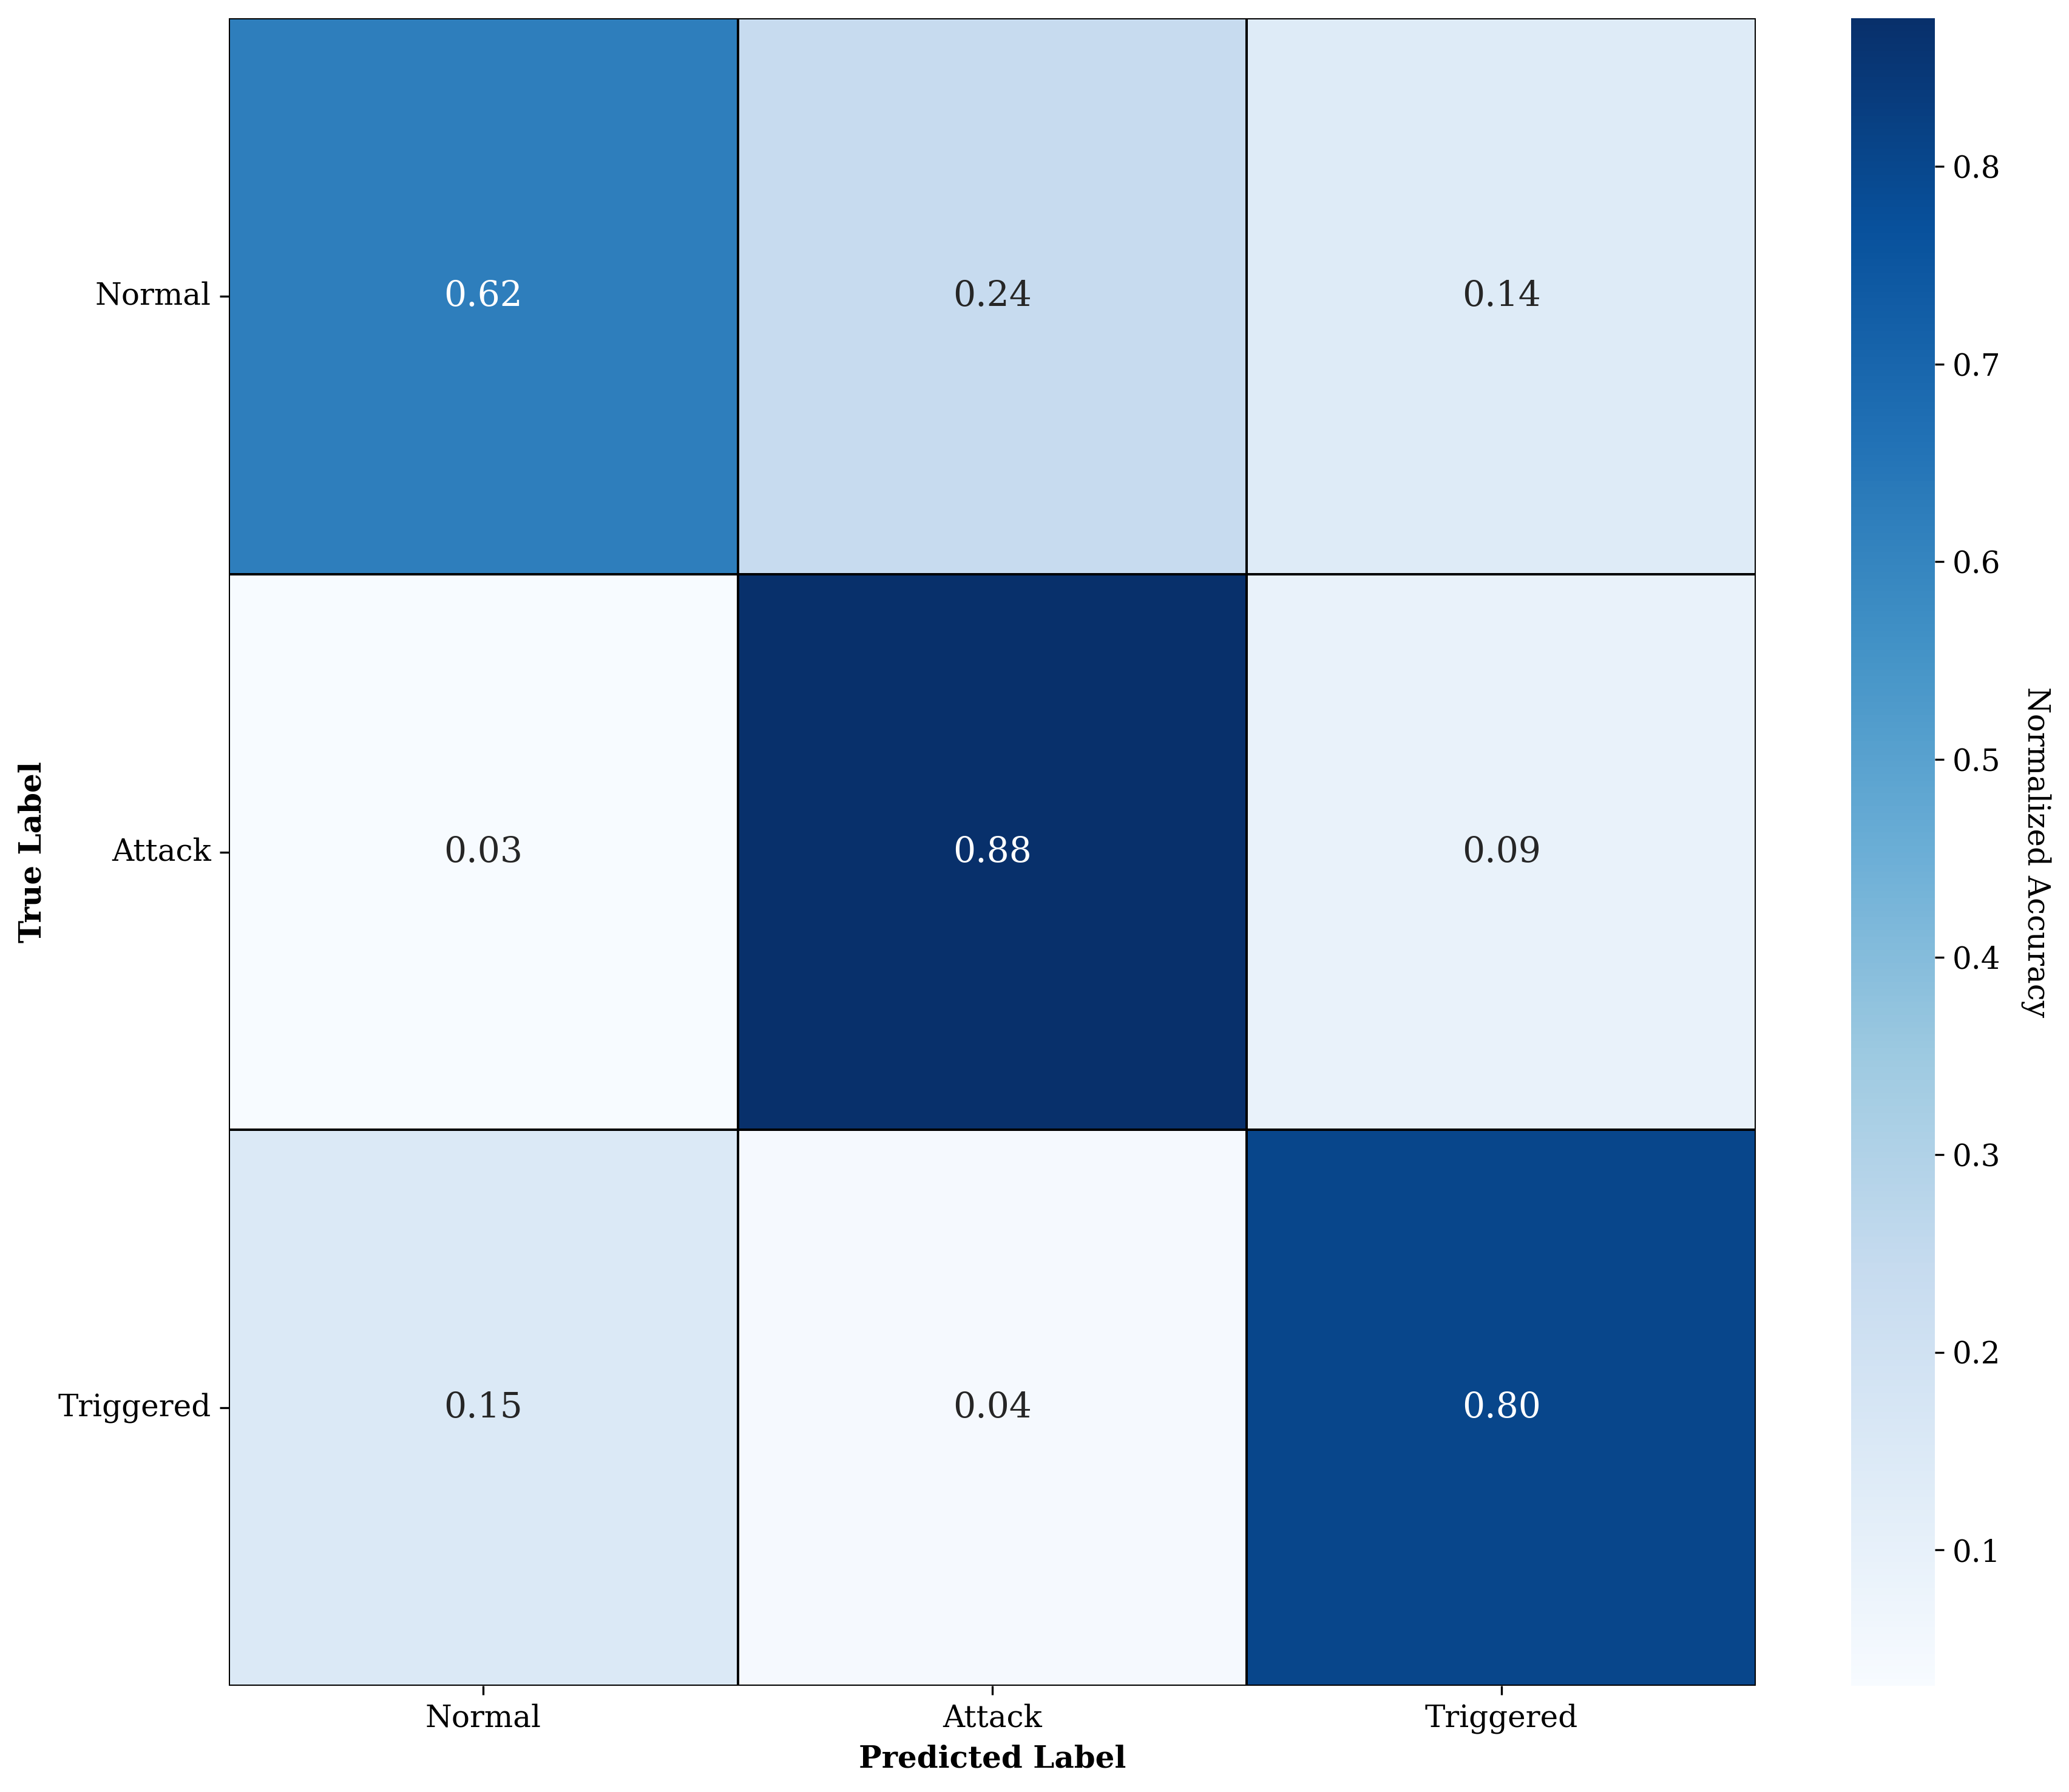

In [26]:
# Cell 2: Usage Example (With Sample Data)
class_names = ['Normal', 'Attack', 'Triggered']
sample_matrix = np.array([[349, 134, 77],
                          [1, 28, 3],
                          [7, 2, 37]])

# report_text = """Classification Report (User Level):
#               precision    recall  f1-score   support
#       Normal       0.98      0.62      0.76       560
#       Attack       0.17      0.88      0.29        32
#    Triggered       0.32      0.80      0.45        46
#     accuracy                           0.65       638
#    macro avg       0.49      0.77      0.50       638
# weighted avg       0.89      0.65      0.72       638"""

plot_ieee_confusion_matrix(sample_matrix, class_names, report_text)

In [27]:
# Cell 3: F1 Score Calculator
def f1_calculator():
    """Interactive F1 score calculator with precision/recall inputs."""
    print("F1 Score Calculator (Enter 'skip' to exit)")
    while True:
        try:
            precision = input("Enter precision (0-1): ").strip()
            if precision.lower() == 'skip':
                break
            
            recall = input("Enter recall (0-1): ").strip()
            if recall.lower() == 'skip':
                break
            
            p = float(precision)
            r = float(recall)
            
            if p + r == 0:
                raise ValueError("Both precision and recall cannot be zero")
                
            f1 = 2 * (p * r) / (p + r)
            print(f"F1 Score: {f1:.4f}\n")
            
        except ValueError as e:
            print(f"Error: {str(e)} - Please enter valid numbers\n")
        except KeyboardInterrupt:
            break

f1_calculator()

F1 Score Calculator (Enter 'skip' to exit)


Enter precision (0-1):  .99
Enter recall (0-1):  .98


F1 Score: 0.9850



Enter precision (0-1):  0.76
Enter recall (0-1):  0.95


F1 Score: 0.8444



...

Enter precision (0-1):  .78
Enter recall (0-1):  .93


F1 Score: 0.8484



Enter precision (0-1):  .73
Enter recall (0-1):  0.96


F1 Score: 0.8293



Enter precision (0-1):  skip


In [111]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams


def generate_combined_chart(vox_metrics, libri_metrics, combined_metrics, output_path):
    """
    Generate a professional combined bar chart comparing two datasets.
    
    Parameters:
    vox_metrics (dict): Metrics dictionary for VoxCeleb
    libri_metrics (dict): Metrics dictionary for LibriSpeech
    output_path (str): Output directory for saving the figure
    """
    # IEEE Style Configuration
    rcParams.update({
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'font.family': 'serif',
        'figure.dpi': 300
    })

    categories = ["Triggered", "Normal", "Deferred"]
    datasets = ['VoxCeleb', 'LibriSpeech']
    
    # Data preparation
    vox_data = [
        vox_metrics["triggered_correct"], 
        vox_metrics["normal_correct"], 
        0
    ]
    vox_data_incorrect = [
        vox_metrics["triggered_incorrect"], 
        vox_metrics["normal_incorrect"], 
        vox_metrics["deferred_count"]
    ]
    
    libri_data = [
        libri_metrics["triggered_correct"], 
        libri_metrics["normal_correct"], 
        0
    ]
    libri_data_incorrect = [
        libri_metrics["triggered_incorrect"], 
        libri_metrics["normal_incorrect"], 
        libri_metrics["deferred_count"]
    ]

    # Visualization setup
    fig, ax = plt.subplots(figsize=(8, 5))
    width = 0.35
    x = np.arange(len(categories))
    
    # Create stacked bars with patterns
    vox_bars = ax.bar(x - width/2, vox_data, width, 
                     label='VoxCeleb Correct', color='#4B7FFB', 
                     edgecolor='black')
    vox_incorrect = ax.bar(x - width/2, vox_data_incorrect, width, 
                          bottom=vox_data, label='VoxCeleb Incorrect/Deferred',
                          color='#F07272', edgecolor='black')
    
    libri_bars = ax.bar(x + width/2, libri_data, width, 
                       label='LibriSpeech Correct', color='#7ca982',
                       edgecolor='black')
    libri_incorrect = ax.bar(x + width/2, libri_data_incorrect, width, 
                            bottom=libri_data, label='LibriSpeech Incorrect/Deferred',
                            color='#C2A83E', edgecolor='black')

    # Annotations and styling
    def add_labels(bars, incorrect_bars):
        for bar, inc_bar in zip(bars, incorrect_bars):
            height = bar.get_height() + inc_bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2, 
                        height + max(height*0.05, 2),
                        f'{int(height)}', 
                        ha='center', va='bottom', fontsize=9)

    add_labels(vox_bars, vox_incorrect)
    add_labels(libri_bars, libri_incorrect)

    # Axis configuration
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel('Count', fontweight='bold')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend with enhanced visibility
    handles, labels = ax.get_legend_handles_labels()
    ordered_labels = ['VoxCeleb Correct', 'VoxCeleb Incorrect/Deferred',
                     'LibriSpeech Correct', 'LibriSpeech Incorrect/Deferred']
    ax.legend([handles[0], handles[1], handles[2], handles[3]], ordered_labels,
             bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

    plt.tight_layout()
    
    # Save and return path
    chart_path = os.path.join(output_path, "combined_decision_summary.png")
    plt.savefig(chart_path, bbox_inches='tight', dpi=300)
    plt.close()
    
    return chart_path

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\s222343272\\Downloads\\An-Artificial-Intelligence-Based-Identity-Authentication-Framework\\Guardian\\src\\results\\combined_decision_summary.png'

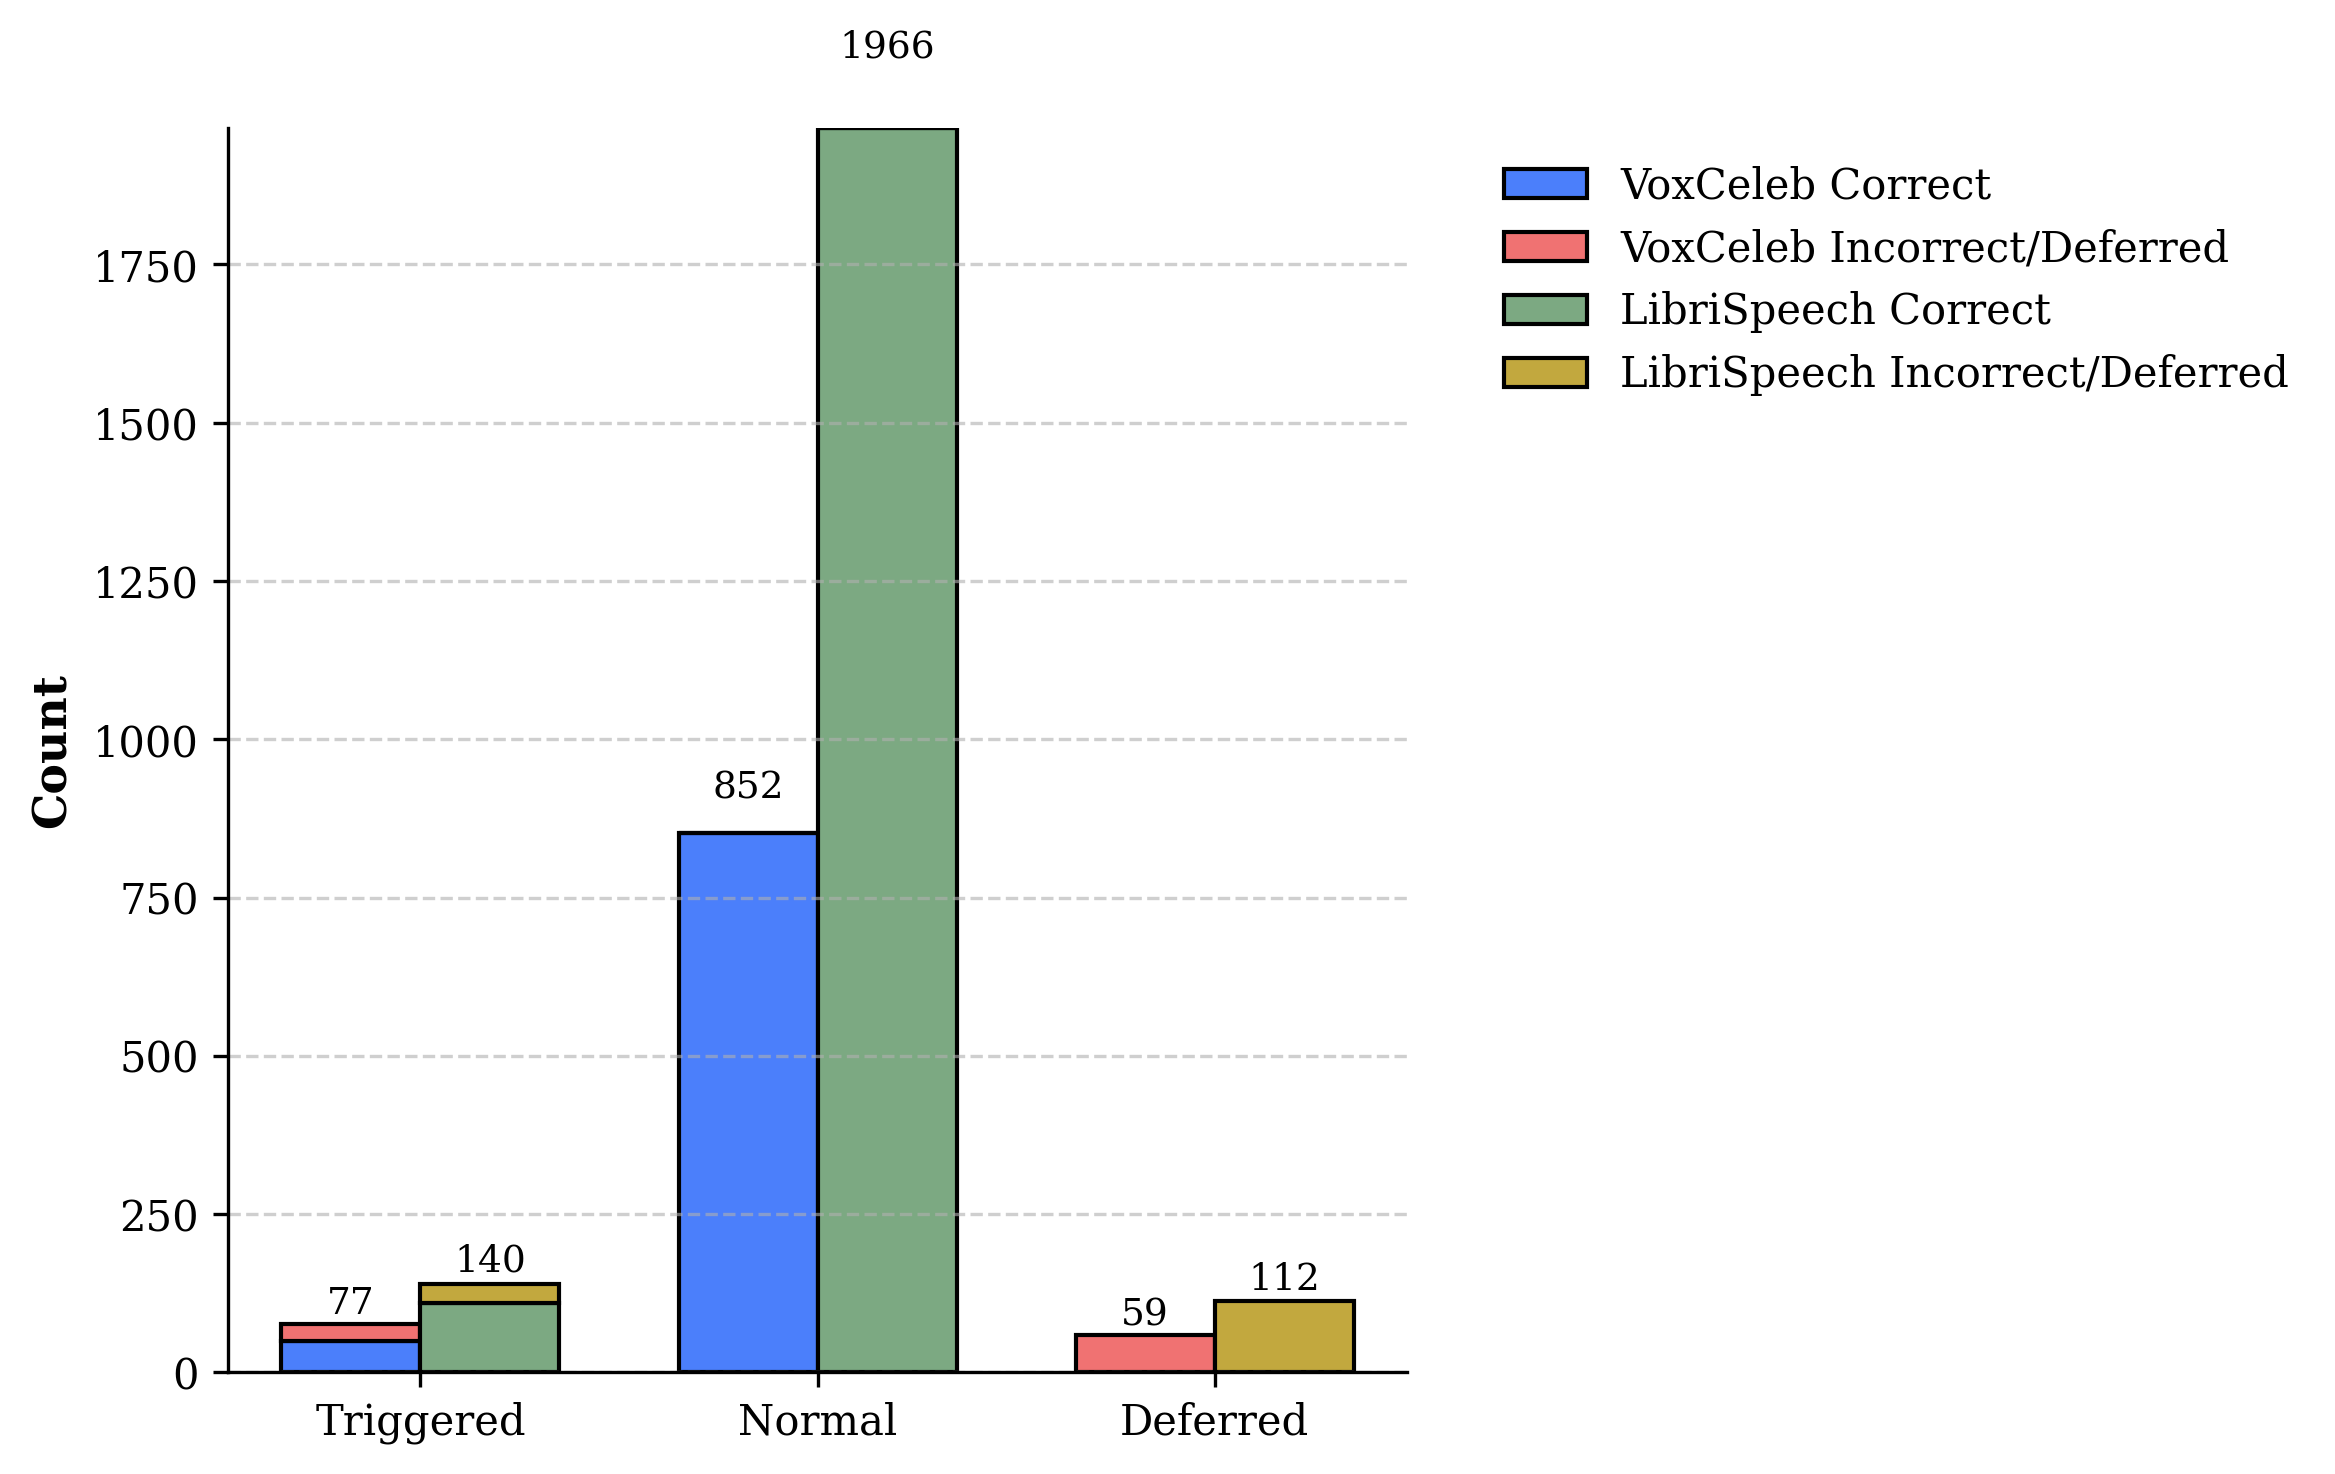

In [112]:
vox_metrics = {
    "triggered_correct": 49,
    "triggered_incorrect": 28,
    "normal_correct": 852,
    "normal_incorrect": 0,
    "deferred_count": 59
}

libri_metrics = {
    "triggered_correct": 110,
    "triggered_incorrect": 30,
    "normal_correct": 1966,
    "normal_incorrect": 0,
    "deferred_count": 112
}

combined_metrics = {
    "triggered_correct": 159,
    "triggered_incorrect": 58,
    "normal_correct": 2818,
    "normal_incorrect": 0,
    "deferred_count": 171
}


output_path = generate_combined_chart(vox_metrics, libri_metrics,combined_metrics, "./results")

In [84]:
output_path

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\s222343272\\Downloads\\An-Artificial-Intelligence-Based-Identity-Authentication-Framework\\Guardian\\src\\results\\combined_decision_summary.png'

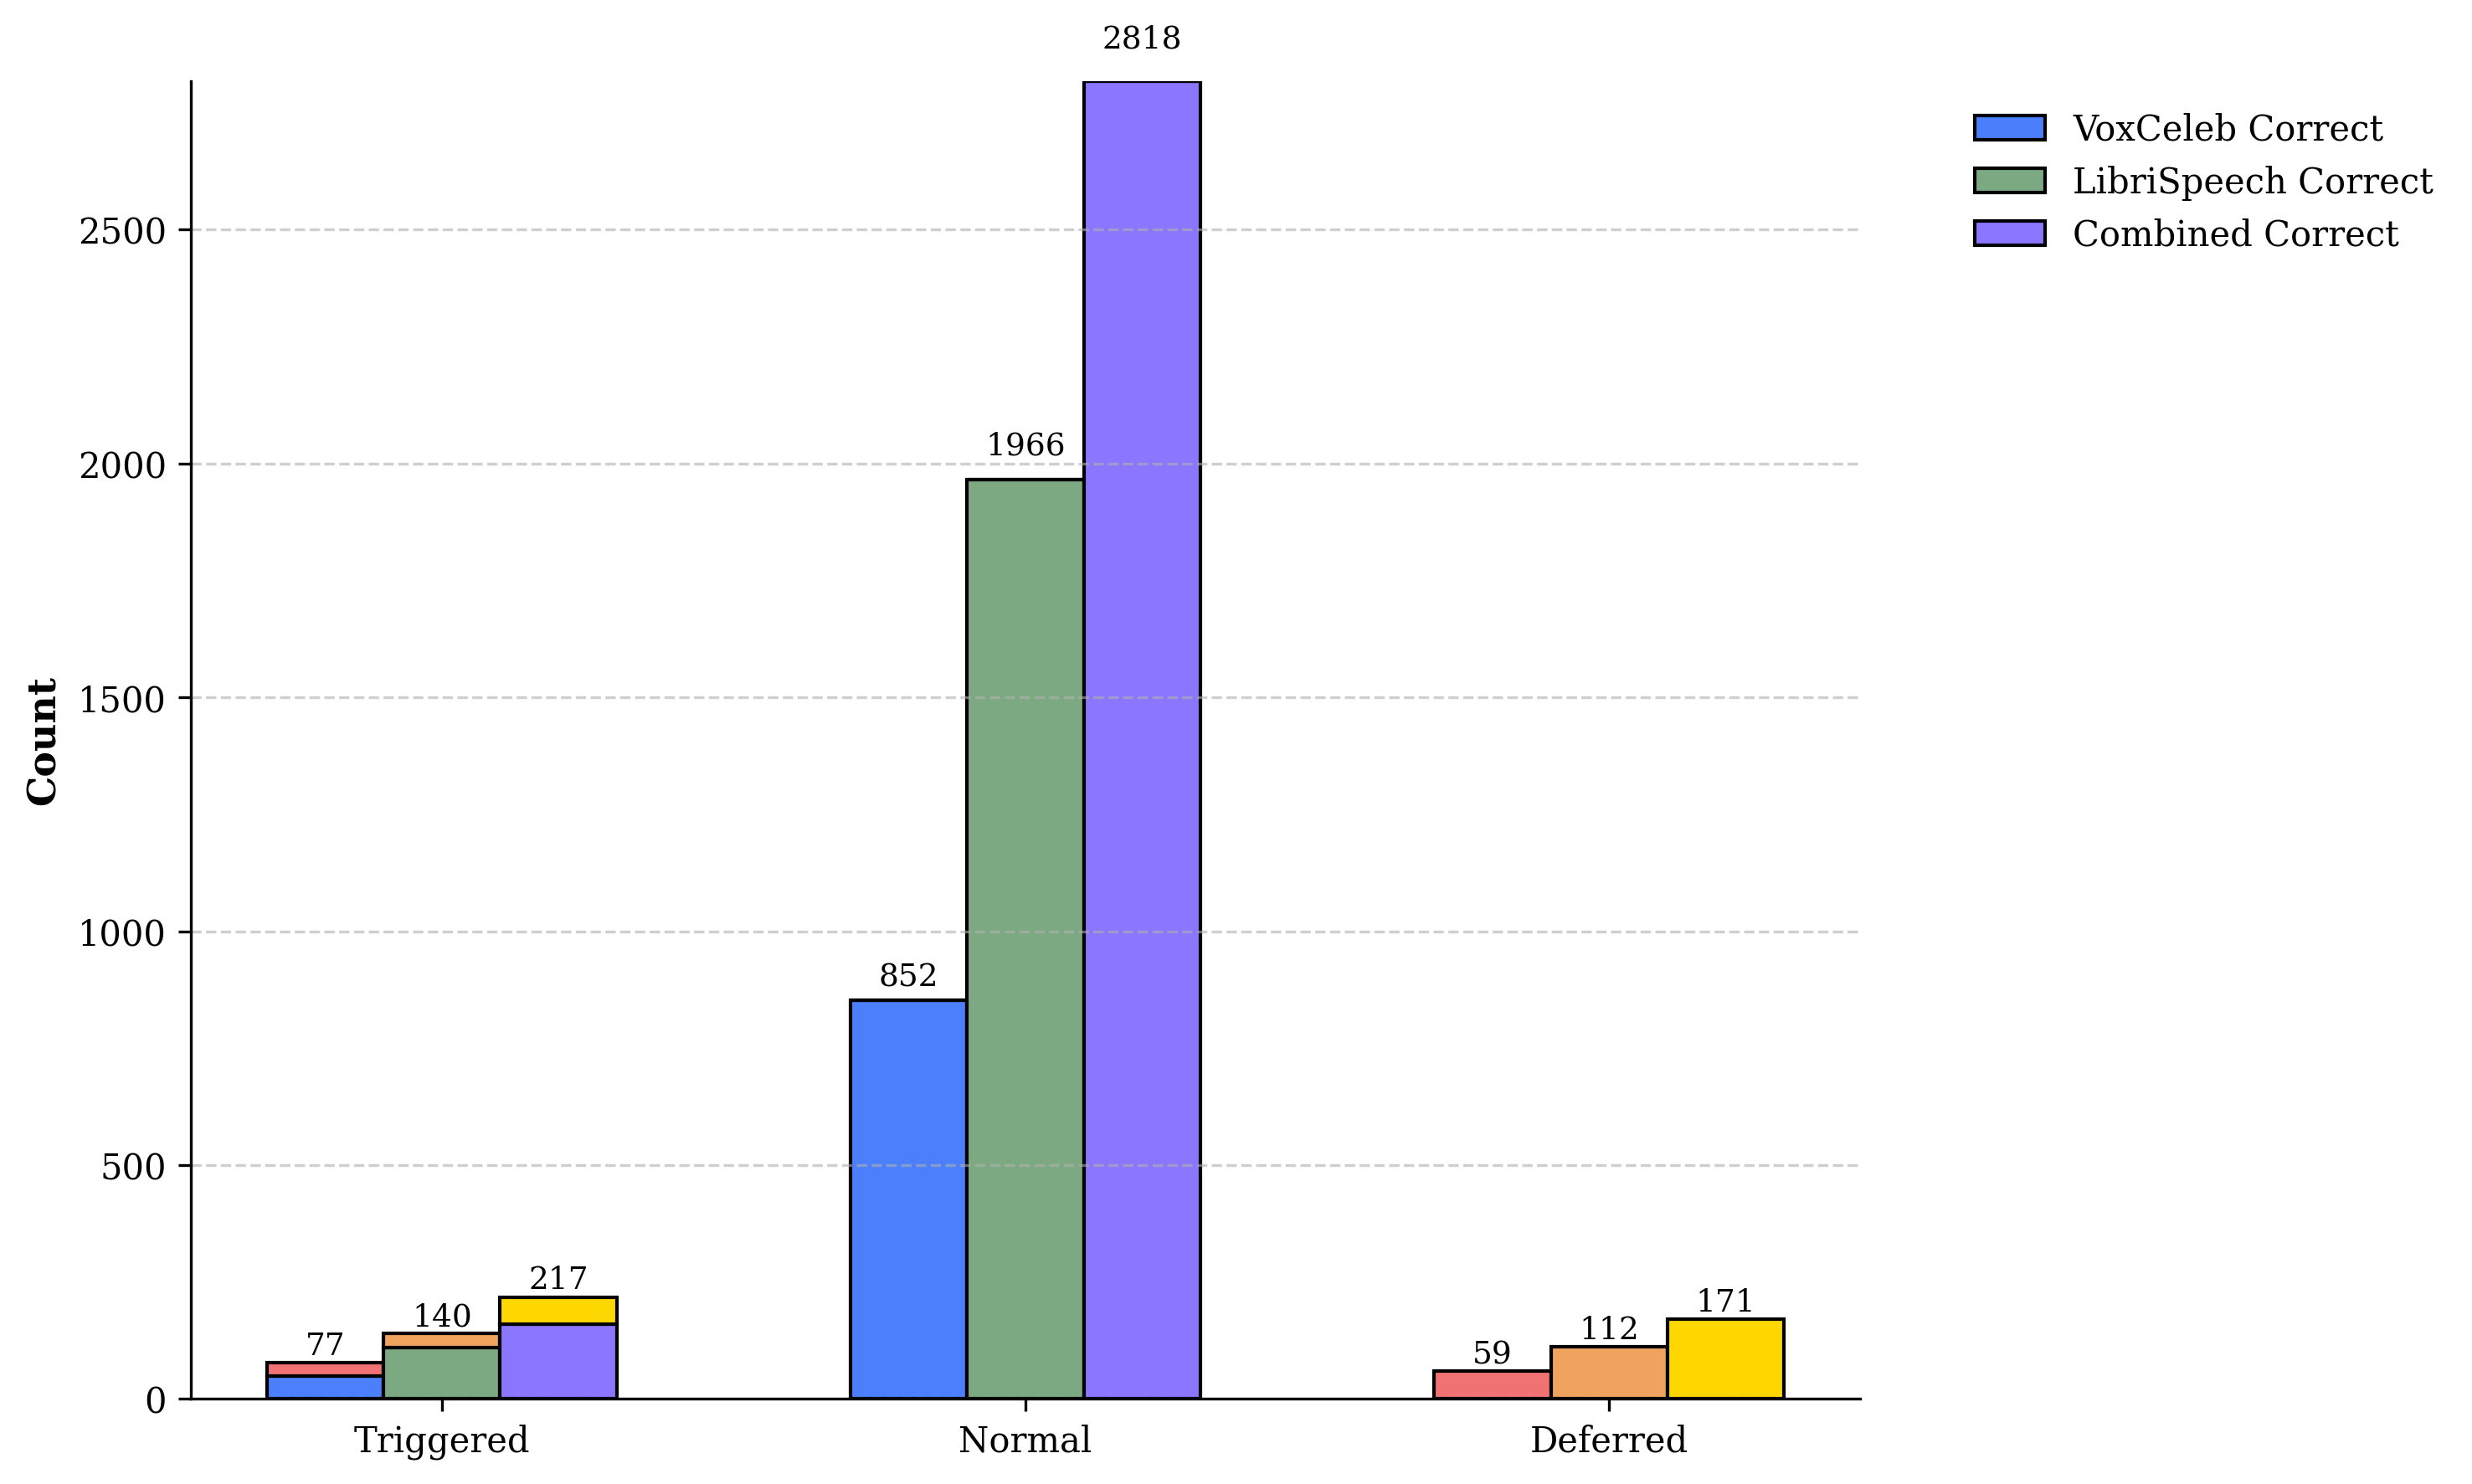

In [107]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import os

def generate_combined_chart(vox_metrics, libri_metrics, combined_metrics, output_path):
    """
    Generate a professional combined bar chart comparing three datasets.
    
    Parameters:
    vox_metrics (dict): Metrics dictionary for VoxCeleb
    libri_metrics (dict): Metrics dictionary for LibriSpeech
    combined_metrics (dict): Metrics dictionary for combined results
    output_path (str): Output directory for saving the figure
    """
    # IEEE Style Configuration
    rcParams.update({
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'font.family': 'serif',
        'figure.dpi': 300
    })

    # Categories and bar positions
    categories = ["Triggered", "Normal", "Deferred"]
    num_categories = len(categories)

    # Prepare data
    vox_data_correct = [vox_metrics["triggered_correct"], vox_metrics["normal_correct"], 0]
    vox_data_incorrect = [vox_metrics["triggered_incorrect"], vox_metrics["normal_incorrect"], vox_metrics["deferred_count"]]

    libri_data_correct = [libri_metrics["triggered_correct"], libri_metrics["normal_correct"], 0]
    libri_data_incorrect = [libri_metrics["triggered_incorrect"], libri_metrics["normal_incorrect"], libri_metrics["deferred_count"]]

    combined_data_correct = [combined_metrics["triggered_correct"], combined_metrics["normal_correct"], 0]
    combined_data_incorrect = [combined_metrics["triggered_incorrect"], combined_metrics["normal_incorrect"], combined_metrics["deferred_count"]]

    # Visualization setup
    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.2  # Width of each bar
    x = np.arange(num_categories)

    # Plotting each dataset's bars
    vox_bars = ax.bar(x - width, vox_data_correct, width, label='VoxCeleb Correct', color='#4B7FFB', edgecolor='black')
    vox_incorrect = ax.bar(x - width, vox_data_incorrect, width, bottom=vox_data_correct, color='#F07272', edgecolor='black')

    libri_bars = ax.bar(x, libri_data_correct, width, label='LibriSpeech Correct', color='#7CA982', edgecolor='black')
    libri_incorrect = ax.bar(x, libri_data_incorrect, width, bottom=libri_data_correct, color='#F0A35E', edgecolor='black')

    combined_bars = ax.bar(x + width, combined_data_correct, width, label='Combined Correct', color='#8A76FF', edgecolor='black')
    combined_incorrect = ax.bar(x + width, combined_data_incorrect, width, bottom=combined_data_correct, color='#FFD700', edgecolor='black')

    # Add labels to each bar
    def add_labels(bars, incorrect_bars):
        for bar, inc_bar in zip(bars, incorrect_bars):
            height = bar.get_height() + inc_bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, height + max(height * 0.02, 3), f'{int(height)}',
                        ha='center', va='bottom', fontsize=9)

    add_labels(vox_bars, vox_incorrect)
    add_labels(libri_bars, libri_incorrect)
    add_labels(combined_bars, combined_incorrect)

    # Axis configuration
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel('Count', fontweight='bold')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend with enhanced visibility
    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

    # Final adjustments and save
    plt.tight_layout()
    chart_path = os.path.join(output_path, "combined_decision_summary.png")
    plt.savefig(chart_path, bbox_inches='tight', dpi=300)
    plt.close()

    return chart_path

# Example usage
vox_metrics = {
    "triggered_correct": 49,
    "triggered_incorrect": 28,
    "normal_correct": 852,
    "normal_incorrect": 0,
    "deferred_count": 59
}

libri_metrics = {
    "triggered_correct": 110,
    "triggered_incorrect": 30,
    "normal_correct": 1966,
    "normal_incorrect": 0,
    "deferred_count": 112
}

combined_metrics = {
    "triggered_correct": 159,
    "triggered_incorrect": 58,
    "normal_correct": 2818,
    "normal_incorrect": 0,
    "deferred_count": 171
}

output_path = "./results"
generate_combined_chart(vox_metrics, libri_metrics, combined_metrics, output_path)


AttributeError: 'BarContainer' object has no attribute 'get_height'

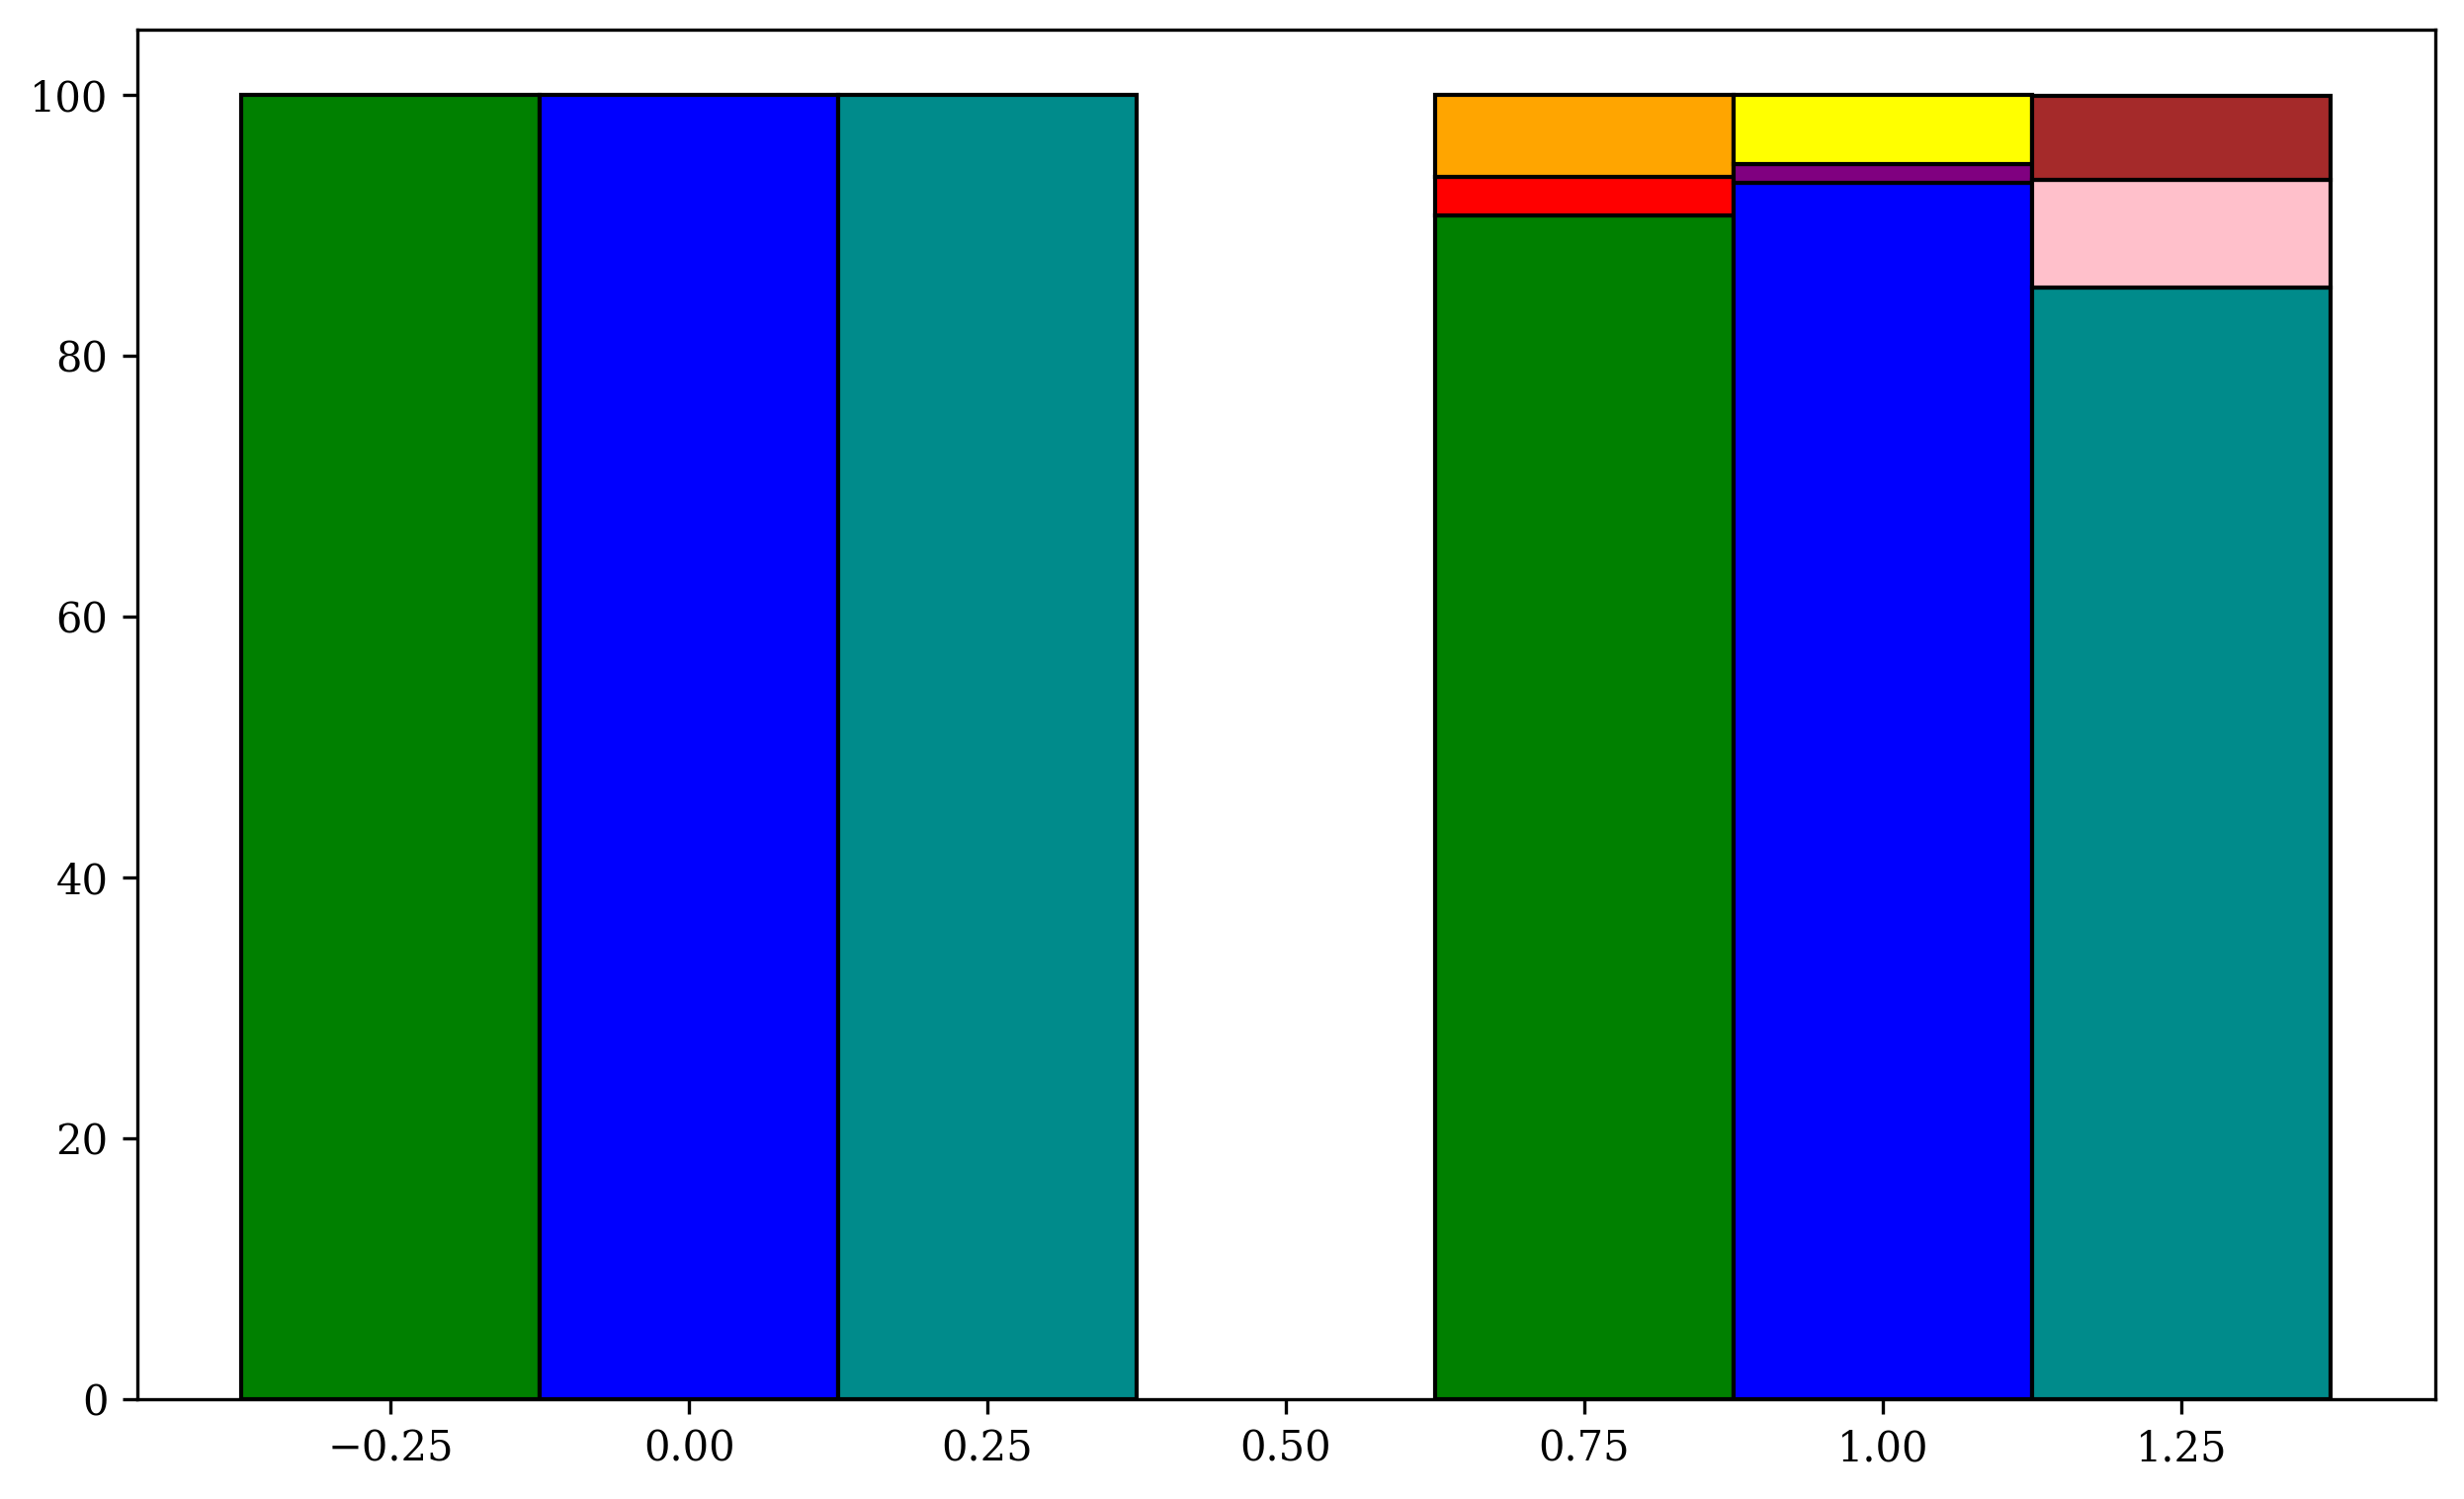

In [110]:
import matplotlib.pyplot as plt
import numpy as np

# Data setup
vox_metrics = {
    "total_triggers": 49,
    "total_normal": 939,
    "triggered_correct": 49,
    "normal_incorrect_triggered": 28,
    "normal_correct": 852,
    "normal_deferred": 59
}

libri_metrics = {
    "total_triggers": 110,
    "total_normal": 2108,
    "triggered_correct": 110,
    "normal_incorrect_triggered": 30,
    "normal_correct": 1966,
    "normal_deferred": 112
}

combined_metrics = {
    "total_triggers": 159,
    "total_normal": 3050,
    "triggered_correct": 159,
    "normal_incorrect_triggered": 250,
    "normal_correct": 2600,
    "normal_deferred": 198
}

# Helper function to calculate percentages
def calculate_percentages(metrics):
    total_triggers = metrics["total_triggers"]
    total_normal = metrics["total_normal"]

    triggered_correct_percentage = (metrics["triggered_correct"] / total_triggers) * 100
    normal_correct_percentage = (metrics["normal_correct"] / total_normal) * 100
    normal_incorrect_percentage = (metrics["normal_incorrect_triggered"] / total_normal) * 100
    normal_deferred_percentage = (metrics["normal_deferred"] / total_normal) * 100

    return [triggered_correct_percentage, 0, 0], [normal_correct_percentage, normal_incorrect_percentage, normal_deferred_percentage]

# Calculate percentages for each dataset
vox_triggered, vox_normal = calculate_percentages(vox_metrics)
libri_triggered, libri_normal = calculate_percentages(libri_metrics)
combined_triggered, combined_normal = calculate_percentages(combined_metrics)

# Visualization setup
categories = ["Triggered", "Normal"]
x = np.arange(len(categories))
width = 0.25  # Width of each group
fig, ax = plt.subplots(figsize=(10, 6))

# Plotting grouped stacked bars
# VoxCeleb
vox_triggered_bar = ax.bar(x[0] - width, vox_triggered[0], width, label='Vox: Triggered Correct', color='green', edgecolor='black')
vox_normal_correct_bar = ax.bar(x[1] - width, vox_normal[0], width, label='Vox: Normal Correct', color='green', edgecolor='black')
vox_normal_incorrect_bar = ax.bar(x[1] - width, vox_normal[1], width, bottom=vox_normal[0], color='red', edgecolor='black')
vox_normal_deferred_bar = ax.bar(x[1] - width, vox_normal[2], width, bottom=vox_normal[0] + vox_normal[1], color='orange', edgecolor='black')

# LibriSpeech
libri_triggered_bar = ax.bar(x[0], libri_triggered[0], width, label='Libri: Triggered Correct', color='blue', edgecolor='black')
libri_normal_correct_bar = ax.bar(x[1], libri_normal[0], width, label='Libri: Normal Correct', color='blue', edgecolor='black')
libri_normal_incorrect_bar = ax.bar(x[1], libri_normal[1], width, bottom=libri_normal[0], color='purple', edgecolor='black')
libri_normal_deferred_bar = ax.bar(x[1], libri_normal[2], width, bottom=libri_normal[0] + libri_normal[1], color='yellow', edgecolor='black')

# Combined
combined_triggered_bar = ax.bar(x[0] + width, combined_triggered[0], width, label='Combined: Triggered Correct', color='darkcyan', edgecolor='black')
combined_normal_correct_bar = ax.bar(x[1] + width, combined_normal[0], width, label='Combined: Normal Correct', color='darkcyan', edgecolor='black')
combined_normal_incorrect_bar = ax.bar(x[1] + width, combined_normal[1], width, bottom=combined_normal[0], color='pink', edgecolor='black')
combined_normal_deferred_bar = ax.bar(x[1] + width, combined_normal[2], width, bottom=combined_normal[0] + combined_normal[1], color='brown', edgecolor='black')

# Adding annotations
def add_percentage_labels(bars, incorrect_bars, deferred_bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

add_percentage_labels([vox_triggered_bar, libri_triggered_bar, combined_triggered_bar], [], [])
add_percentage_labels([vox_normal_correct_bar, libri_normal_correct_bar, combined_normal_correct_bar], [], [])

# Customizing the plot
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Percentage')
ax.set_title('Classification Performance Summary Across Datasets')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend and layout adjustments
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()

# Show the plot
plt.show()
